## 1 · Setup & Configuration

In [1]:
import sys, json, random, types
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.notebook import tqdm

from src.eval.evaluate import (
    normalize_answer, exact_match, bleu1, token_f1, sp_metrics,
    mrr_score, hit_at_k,
    extract_final_answer,
    build_pipeline as build_hotpotqa_pipeline,
    normalize_label, label_accuracy, evidence_metrics, fever_score,
    extract_final_verdict,
    build_fever_pipeline,
)
from src.eval.faithfulness import (
    faithfulness_score_qa, faithfulness_score_fever, HALLUCINATION_THRESHOLD,
)
from src.eval.trust_metrics import extract_key_facts, transparency_score

In [2]:
print(f'Project root: {ROOT}')

Project root: /Users/bercaakbayir/Desktop/projects/unimi-dse-nlp-assignment


In [3]:
SAMPLE_SIZE = 50

Each experiment will be run with 50 random questions.

In [4]:
CFG = types.SimpleNamespace(
    limit       = SAMPLE_SIZE,
    seed        = 42,
    poison_seed = 42,
    top_k       = 10,
    llm         = 'llama3.2:3b',
    embed_model = 'sentence-transformers/all-MiniLM-L12-v2',
)

CFG is a setting variable that stores the variables for the experiment. Sample size is determined at the beginnning of the project. Seed and poison seed has determined as same value to ensure the consistency across experiments so that experiments can be run and evaluated with same questions. Retriever returns the top 10 most relevant documents. llama3.2:3b is chosen for LLM, MiniLM L12 v2 is chosen as embedding model for the RAG system.

In [5]:
RESULTS_DIR  = ROOT / 'results'
HOTPOTQA_VAL = ROOT / 'data' / 'hotpotqa' / 'validation.jsonl'
FEVER_VAL    = ROOT / 'data' / 'fever'    / 'paper_dev.jsonl'
RESULTS_DIR.mkdir(exist_ok=True)

In [6]:
PATHS = {
    'hotpotqa_clean':               RESULTS_DIR / 'hotpotqa_clean.jsonl',
    'hotpotqa_poisoned':            RESULTS_DIR / 'hotpotqa_poisoned.jsonl',
    'hotpotqa_poisoned_consistency':RESULTS_DIR / 'hotpotqa_poisoned_consistency.jsonl',
    'fever_clean':                  RESULTS_DIR / 'fever_clean.jsonl',
    'fever_poisoned':               RESULTS_DIR / 'fever_poisoned.jsonl',
    'fever_poisoned_consistency':   RESULTS_DIR / 'fever_poisoned_consistency.jsonl',
}
print('Config ready.')
print('Hallucination threshold:', HALLUCINATION_THRESHOLD)

Config ready.
Hallucination threshold: 0.5


## 2 · Run Evaluations

This function defines the full evaluation pipeline run over HotpotQA dataset. It starts with sampling from all data with pre-determined sample size. This function ensures that if the experiment break at some point, it can gracefully continue from the question where it stopped using cached results. It calls the evlauation pipeline from src/eval/evaluation python file for specifically HotpotQA with the necessary parameters. This pipeline is defined with build_pipeline function. This function is composition of Retriever, LLM and Poisoning Layer. It calls Hybrid Retriever if it can find BM25 indexes, or dense retriever otherwise. Poisoning level has been determined as %30 for retrieved documents inside of the PassagePoisoner function. It also receives the consistency check as parameter to enable this feature as another experiment. It can call the specific prompt to check the consistency across documents. 

As second step of the pipeline, it starts the run and create the evaluation metrics. It compares the RAG answers and real answers which are from answers for HotpotQA, label for Fever dataset. This comparison is ongoing during the sampled questions. Recall, precision, f1, exact matches are defined here as metrics. Hallucination rate threshold is determined as 0.5 at the beginning. The hallucination rate is measured using an NLI-based faithfulness scorer. For each generated answer, the concatenated retrieved passages are used as the premise and the answer is converted into a hypothesis — for QA tasks this is "The answer is: {answer}", for SUPPORTS verdicts it's the claim itself, and for REFUTES it's "The following claim is false: {claim}". The cross-encoder/nli-deberta-v3-small model then computes a softmax over three logits (contradiction, neutral, entailment) and the entailment probability is taken as the faithfulness score. Any score below 0.5 is flagged as a hallucination, and the hallucination rate is simply the fraction of answers that fall below this threshold across the evaluated sample. 

In [ ]:
def run_hotpotqa(
    output_path: Path,
    poison: bool = False,
    poison_seed: int | None = None,
    consistency_check: bool = False,
) -> list[dict]:
    output_path = Path(output_path)
    samples = random.Random(CFG.seed).sample(
        [json.loads(l) for l in HOTPOTQA_VAL.read_text().splitlines() if l.strip()],
        CFG.limit,
    )

    already_done: set[str] = set()
    all_records: list[dict] = []
    if output_path.exists():
        for line in output_path.read_text().splitlines():
            if line.strip():
                rec = json.loads(line)
                # Only completed (non-error) rows count as done, so a transient
                # failure (e.g. Ollama down) is retried instead of cached as "complete".
                if rec.get('error') is None:
                    already_done.add(rec['id'])
                    all_records.append(rec)

    pending = [s for s in samples if s['id'] not in already_done]
    if not pending:
        print(f'  [skip] {output_path.name}: complete ({len(all_records)} records)')
        return all_records
    print(f'  {output_path.name}: {len(already_done)} done, {len(pending)} remaining')

    args = types.SimpleNamespace(
        collection        = 'hotpotqa_passages',
        embed_model       = CFG.embed_model,
        top_k             = CFG.top_k,
        llm               = CFG.llm,
        poison            = poison,
        poison_seed       = poison_seed,
        consistency_check = consistency_check,
    )
    pipeline = build_hotpotqa_pipeline(args)

    with open(output_path, 'a', encoding='utf-8') as out_f:
        for sample in tqdm(pending, desc=output_path.stem):
            record: dict = {'id': sample['id'], 'type': sample['type'], 'question': sample['question']}
            try:
                result      = pipeline.answer(sample['question'])
                pred        = extract_final_answer(result['answer'])
                gold        = sample['answer']
                ret_titles  = [s['title'] for s in result['sources']]
                gold_titles = list(set(sample['supporting_facts']['title']))
                sp_p, sp_r, sp_f = sp_metrics(ret_titles, gold_titles)
                faith = faithfulness_score_qa(pred, result['sources'])
                full_output = result['answer']
                key_facts   = extract_key_facts(sample)
                transp      = transparency_score(full_output, key_facts)
                record.update({
                    'gold_answer':              gold,
                    'pred_answer':              pred,
                    'em':                       exact_match(pred, gold),
                    'bleu1':                    bleu1(pred, gold),
                    'f1':                       token_f1(pred, gold),
                    'sp_precision':             sp_p,
                    'sp_recall':                sp_r,
                    'sp_f1':                    sp_f,
                    'mrr':                      mrr_score(ret_titles, gold_titles),
                    'hit_1':                    hit_at_k(ret_titles, gold_titles, 1),
                    'hit_3':                    hit_at_k(ret_titles, gold_titles, 3),
                    'hit_5':                    hit_at_k(ret_titles, gold_titles, 5),
                    'retrieved_titles':         ret_titles,
                    'gold_titles':              gold_titles,
                    'poisoning_enabled':        poison,
                    'poisoned_count':           sum(1 for s in result['sources'] if s.get('poisoned')),
                    'poisoned_titles':          [s['title'] for s in result['sources'] if s.get('poisoned')],
                    'faithfulness_score':       faith,
                    'is_hallucination':         faith < HALLUCINATION_THRESHOLD,
                    'consistency_check_enabled': consistency_check,
                    'full_output':              full_output,
                    'key_facts':                key_facts,
                    'n_key_facts':              len(key_facts),
                    'transparency_score':       transp,
                    'error':                    None,
                })
            except Exception as e:
                record.update({'error': str(e), 'gold_answer': sample['answer']})
            all_records.append(record)
            out_f.write(json.dumps(record) + '\n')
            out_f.flush()

    print(f'  Saved -> {output_path}')
    return all_records

In [ ]:
def run_fever(
    output_path: Path,
    poison: bool = False,
    poison_seed: int | None = None,
    consistency_check: bool = False,
) -> list[dict]:
    output_path = Path(output_path)
    samples = random.Random(CFG.seed).sample(
        [json.loads(l) for l in FEVER_VAL.read_text().splitlines() if l.strip()],
        CFG.limit,
    )

    already_done: set[int] = set()
    all_records: list[dict] = []
    if output_path.exists():
        for line in output_path.read_text().splitlines():
            if line.strip():
                rec = json.loads(line)
                # Only completed (non-error) rows count as done, so a transient
                # failure (e.g. Ollama down) is retried instead of cached as "complete".
                if rec.get('error') is None:
                    already_done.add(rec['id'])
                    all_records.append(rec)

    pending = [s for s in samples if s['id'] not in already_done]
    if not pending:
        print(f'  [skip] {output_path.name}: complete ({len(all_records)} records)')
        return all_records
    print(f'  {output_path.name}: {len(already_done)} done, {len(pending)} remaining')

    args = types.SimpleNamespace(
        collection        = 'fever_passages',
        embed_model       = CFG.embed_model,
        top_k             = CFG.top_k,
        llm               = CFG.llm,
        poison            = poison,
        poison_seed       = poison_seed,
        consistency_check = consistency_check,
    )
    pipeline = build_fever_pipeline(args)

    with open(output_path, 'a', encoding='utf-8') as out_f:
        for sample in tqdm(pending, desc=output_path.stem):
            record: dict = {'id': sample['id'], 'claim': sample['claim']}
            try:
                result     = pipeline.answer(sample['claim'])
                pred       = extract_final_verdict(result['answer'])
                gold       = sample['label']
                ret_titles = [s['title'] for s in result['sources']]
                gold_titles = list({
                    piece[2].replace('_', ' ')
                    for ann_set in sample.get('evidence', [])
                    for piece in ann_set
                    if len(piece) >= 3 and piece[2]
                })
                ev_p, ev_r, ev_f = evidence_metrics(ret_titles, gold_titles)
                faith = faithfulness_score_fever(pred, sample['claim'], result['sources'])
                record.update({
                    'gold_label':               gold,
                    'pred_label':               pred,
                    'pred_normalized':          normalize_label(pred),
                    'label_acc':                label_accuracy(pred, gold),
                    'fever_sc':                 fever_score(pred, gold, ret_titles, gold_titles),
                    'ev_precision':             ev_p,
                    'ev_recall':                ev_r,
                    'ev_f1':                    ev_f,
                    'mrr':                      mrr_score(ret_titles, gold_titles),
                    'hit_1':                    hit_at_k(ret_titles, gold_titles, 1),
                    'hit_3':                    hit_at_k(ret_titles, gold_titles, 3),
                    'hit_5':                    hit_at_k(ret_titles, gold_titles, 5),
                    'retrieved_titles':         ret_titles,
                    'gold_titles':              gold_titles,
                    'poisoning_enabled':        poison,
                    'poisoned_count':           sum(1 for s in result['sources'] if s.get('poisoned')),
                    'poisoned_titles':          [s['title'] for s in result['sources'] if s.get('poisoned')],
                    'faithfulness_score':       faith,
                    'is_hallucination':         faith < HALLUCINATION_THRESHOLD,
                    'consistency_check_enabled': consistency_check,
                    'error':                    None,
                })
            except Exception as e:
                record.update({'error': str(e), 'gold_label': sample['label']})
            all_records.append(record)
            out_f.write(json.dumps(record) + '\n')
            out_f.flush()

    print(f'  Saved -> {output_path}')
    return all_records

All experiments have been run here as follows:
1. Base RAG for HotpotQA (no poisoning, base prompt)
2. RAG with posioned passages in retriever component for HotpotQA
3. RAG with posioned passages in retriever component and additional consistency check prompt for HotpotQA
4. Base RAG for Fever (no poisoning, base prompt)
5. RAG with posioned passages in retriever component for Fever
6. RAG with posioned passages in retriever component and additional consistency check prompt for Fever

In [9]:
# print('=' * 65)
print('Running all 6 experiments  (resume-safe)')
print('=' * 65)

print('\n[1/6] HotpotQA — Clean')
run_hotpotqa(PATHS['hotpotqa_clean'], poison=False)

print('\n[2/6] HotpotQA — Poisoned')
run_hotpotqa(PATHS['hotpotqa_poisoned'], poison=True, poison_seed=CFG.poison_seed)

print('\n[3/6] HotpotQA — Poisoned + Consistency')
run_hotpotqa(PATHS['hotpotqa_poisoned_consistency'],
             poison=True, poison_seed=CFG.poison_seed, consistency_check=True)

print('\n[4/6] FEVER — Clean')
run_fever(PATHS['fever_clean'], poison=False)

print('\n[5/6] FEVER — Poisoned')
run_fever(PATHS['fever_poisoned'], poison=True, poison_seed=CFG.poison_seed)

print('\n[6/6] FEVER — Poisoned + Consistency')
run_fever(PATHS['fever_poisoned_consistency'],
          poison=True, poison_seed=CFG.poison_seed, consistency_check=True)

print('\nAll 6 experiments complete!')

Running all 6 experiments  (resume-safe)

[1/6] HotpotQA — Clean
  hotpotqa_clean.jsonl: 0 done, 50 remaining


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

hotpotqa_clean:   0%|          | 0/50 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Saved -> /Users/bercaakbayir/Desktop/projects/unimi-dse-nlp-assignment/results/hotpotqa_clean.jsonl

[2/6] HotpotQA — Poisoned
  hotpotqa_poisoned.jsonl: 0 done, 50 remaining


hotpotqa_poisoned:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved -> /Users/bercaakbayir/Desktop/projects/unimi-dse-nlp-assignment/results/hotpotqa_poisoned.jsonl

[3/6] HotpotQA — Poisoned + Consistency
  hotpotqa_poisoned_consistency.jsonl: 0 done, 50 remaining


hotpotqa_poisoned_consistency:   0%|          | 0/50 [00:00<?, ?it/s]

  Saved -> /Users/bercaakbayir/Desktop/projects/unimi-dse-nlp-assignment/results/hotpotqa_poisoned_consistency.jsonl

[4/6] FEVER — Clean
  [skip] fever_clean.jsonl: complete (50 records)

[5/6] FEVER — Poisoned
  [skip] fever_poisoned.jsonl: complete (50 records)

[6/6] FEVER — Poisoned + Consistency
  [skip] fever_poisoned_consistency.jsonl: complete (50 records)

All 6 experiments complete!


## 3 · Load Results

In [10]:
def load_jsonl(path: Path) -> pd.DataFrame:
    records = [json.loads(l) for l in Path(path).read_text().splitlines() if l.strip()]
    return pd.DataFrame([r for r in records if r.get('error') is None])

CONDITION_LABELS = {
    'hotpotqa_clean':               ('HotpotQA', 'clean'),
    'hotpotqa_poisoned':            ('HotpotQA', 'poisoned'),
    'hotpotqa_poisoned_consistency':('HotpotQA', 'poisoned+consistency'),
    'fever_clean':                  ('FEVER',    'clean'),
    'fever_poisoned':               ('FEVER',    'poisoned'),
    'fever_poisoned_consistency':   ('FEVER',    'poisoned+consistency'),
}

dfs = {}
for key, (dataset, condition) in CONDITION_LABELS.items():
    dfs[key] = load_jsonl(PATHS[key]).assign(dataset=dataset, condition=condition)
    print(f'  {key}: {len(dfs[key])} records')

hq_clean    = dfs['hotpotqa_clean']
hq_poisoned = dfs['hotpotqa_poisoned']
hq_consist  = dfs['hotpotqa_poisoned_consistency']
fv_clean    = dfs['fever_clean']
fv_poisoned = dfs['fever_poisoned']
fv_consist  = dfs['fever_poisoned_consistency']

hq = pd.concat([hq_clean, hq_poisoned, hq_consist], ignore_index=True)
fv = pd.concat([fv_clean, fv_poisoned, fv_consist], ignore_index=True)

COND_ORDER = ['clean', 'poisoned', 'poisoned+consistency']

  hotpotqa_clean: 50 records
  hotpotqa_poisoned: 50 records
  hotpotqa_poisoned_consistency: 50 records
  fever_clean: 50 records
  fever_poisoned: 50 records
  fever_poisoned_consistency: 50 records


Each record can be seen here as 50 which comes from the sample size.

## 4 · HotpotQA Analysis

In [11]:
HQ_METRICS = {
    'em': 'EM', 'bleu1': 'BLEU-1', 'f1': 'Token F1',
    'sp_precision': 'SP Precision', 'sp_recall': 'SP Recall', 'sp_f1': 'SP F1',
    'transparency_score': 'Transparency',
}

# Keep only metrics present in the loaded data (legacy result files may lack transparency_score).
present_metrics = [m for m in HQ_METRICS if m in hq.columns]

hq_summary = (
    hq.groupby('condition')[present_metrics].mean()
      .reindex(COND_ORDER).mul(100).round(1)
      .rename(columns=HQ_METRICS).T
)
hq_summary.columns.name = None
hq_summary.index.name = 'Metric'
hq_summary['Δ poison-clean']       = (hq_summary['poisoned']             - hq_summary['clean']).round(1)
hq_summary['Δ consistency-poison'] = (hq_summary['poisoned+consistency'] - hq_summary['poisoned']).round(1)

print('HotpotQA — Answer Quality (3-condition overview)\n')
display(hq_summary.style.format('{:.1f}')
        .background_gradient(cmap='RdYlGn', subset=list(COND_ORDER), axis=None))

HotpotQA — Answer Quality (3-condition overview)



,clean,poisoned,poisoned+consistency,Δ poison-clean,Δ consistency-poison
Metric,,,,,
EM,26.0,28.0,24.0,2.0,-4.0
BLEU-1,34.5,35.6,27.4,1.1,-8.2
Token F1,40.0,39.8,30.8,-0.2,-9.0
SP Precision,18.2,18.2,18.2,0.0,0.0
SP Recall,78.0,78.0,78.0,0.0,0.0
SP F1,29.4,29.4,29.4,0.0,0.0
Transparency,76.3,80.6,75.0,4.3,-5.6


In [12]:
HQ_RETRIEVER = {'mrr': 'MRR', 'hit_1': 'Hit@1', 'hit_3': 'Hit@3', 'hit_5': 'Hit@5'}

hq_ret = (
    hq.groupby('condition')[list(HQ_RETRIEVER)].mean()
      .reindex(COND_ORDER).mul(100).round(1)
      .rename(columns=HQ_RETRIEVER).T
)
hq_ret.columns.name = None
hq_ret.index.name = 'Metric'
hq_ret['Δ poison-clean']       = (hq_ret['poisoned']             - hq_ret['clean']).round(1)
hq_ret['Δ consistency-poison'] = (hq_ret['poisoned+consistency'] - hq_ret['poisoned']).round(1)

print('HotpotQA — Retriever Quality: rank-aware metrics\n')
print('MRR = reciprocal rank of first gold passage; Hit@k = any gold in top-k\n')
display(hq_ret.style.format('{:.1f}')
        .background_gradient(cmap='RdYlGn', subset=list(COND_ORDER), axis=None))

HotpotQA — Retriever Quality: rank-aware metrics

MRR = reciprocal rank of first gold passage; Hit@k = any gold in top-k



,clean,poisoned,poisoned+consistency,Δ poison-clean,Δ consistency-poison
Metric,,,,,
MRR,82.4,82.4,82.4,0.0,0.0
Hit@1,76.0,76.0,76.0,0.0,0.0
Hit@3,88.0,88.0,88.0,0.0,0.0
Hit@5,88.0,88.0,88.0,0.0,0.0


Before moving through the LLM performance, retriever performance must be investigated over SP Precision & Recall. SP Precision is aroun %18 so it means that among top 10 retrieved documents, only 1-2 documents were gold standart. On the other hand, SP Recall is around %80 so it means 1 or 2 documents among 2 gold standart retrieved documents is completely related. 

F1 Token measures the word-level overlapping between real and predicted answer. 


In [13]:
hq_type = (
    hq.groupby(['type', 'condition'])[['em', 'f1', 'sp_f1']].mean()
       .mul(100).round(1)
       .rename(columns={'em': 'EM', 'f1': 'Token F1', 'sp_f1': 'SP F1'})
       .unstack('condition').reindex(columns=pd.MultiIndex.from_product(
           [['EM', 'Token F1', 'SP F1'], COND_ORDER]))
)
print('HotpotQA — Breakdown by question type\n')
display(hq_type.style.format('{:.1f}'))

HotpotQA — Breakdown by question type



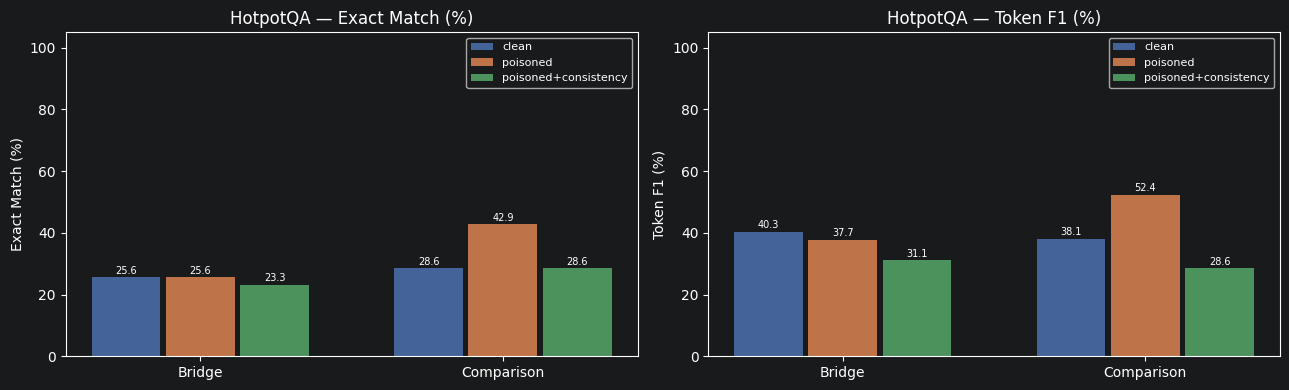

In [14]:
COND_COLORS = {'clean': '#4C72B0', 'poisoned': '#DD8452', 'poisoned+consistency': '#55A868'}
x_offsets   = {'clean': 0.0,       'poisoned': 0.27,      'poisoned+consistency': 0.54}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (metric, ylabel) in zip(axes, [('em', 'Exact Match (%)'), ('f1', 'Token F1 (%)')]):
    for cond, color in COND_COLORS.items():
        vals = hq[hq['condition'] == cond].groupby(hq['type'])[metric].mean().mul(100)
        for i, qtype in enumerate(['bridge', 'comparison']):
            x = i * 1.1 + x_offsets[cond]
            h = vals.get(qtype, 0)
            bar = ax.bar(x, h, width=0.25, color=color, alpha=0.85,
                         label=cond if i == 0 else '')
            ax.text(x, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks([0.27, 1.37])
    ax.set_xticklabels(['Bridge', 'Comparison'])
    ax.set_ylabel(ylabel); ax.set_title(f'HotpotQA — {ylabel}')
    ax.legend(fontsize=8); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hotpotqa_3cond.png', dpi=150)
plt.show()

## 5 · FEVER Analysis

**Metrics:** Label Accuracy, FEVER Score, Evidence Precision/Recall/F1

In [15]:
# FEVER is a classification task — Label Accuracy and FEVER Score are the primary metrics.
# Evidence P/R/F1 measure retriever quality at the set level (complement to MRR/Hit@k below).
FV_METRICS = {
    'label_acc': 'Label Accuracy', 'fever_sc': 'FEVER Score',
    'ev_precision': 'Ev. Precision', 'ev_recall': 'Ev. Recall', 'ev_f1': 'Ev. F1',
}

fv_summary = (
    fv.groupby('condition')[list(FV_METRICS)].mean()
      .reindex(COND_ORDER).mul(100).round(1)
      .rename(columns=FV_METRICS).T
)
fv_summary.columns.name = None
fv_summary.index.name = 'Metric'
fv_summary['Δ poison-clean']       = (fv_summary['poisoned']             - fv_summary['clean']).round(1)
fv_summary['Δ consistency-poison'] = (fv_summary['poisoned+consistency'] - fv_summary['poisoned']).round(1)

print('FEVER — Classification & Evidence Quality (3-condition overview)\n')
display(fv_summary.style.format('{:.1f}')
        .background_gradient(cmap='RdYlGn', subset=list(COND_ORDER), axis=None))

FEVER — Classification & Evidence Quality (3-condition overview)



,clean,poisoned,poisoned+consistency,Δ poison-clean,Δ consistency-poison
Metric,,,,,
Label Accuracy,66.0,58.0,54.0,-8.0,-4.0
FEVER Score,58.0,50.0,48.0,-8.0,-2.0
Ev. Precision,37.4,37.4,37.4,0.0,0.0
Ev. Recall,60.0,60.0,60.0,0.0,0.0
Ev. F1,43.4,43.4,43.4,0.0,0.0


In [16]:
FV_RETRIEVER = {'mrr': 'MRR', 'hit_1': 'Hit@1', 'hit_3': 'Hit@3', 'hit_5': 'Hit@5'}

fv_ret = (
    fv.groupby('condition')[list(FV_RETRIEVER)].mean()
      .reindex(COND_ORDER).mul(100).round(1)
      .rename(columns=FV_RETRIEVER).T
)
fv_ret.columns.name = None
fv_ret.index.name = 'Metric'
fv_ret['Δ poison-clean']       = (fv_ret['poisoned']             - fv_ret['clean']).round(1)
fv_ret['Δ consistency-poison'] = (fv_ret['poisoned+consistency'] - fv_ret['poisoned']).round(1)

print('FEVER — Retriever Quality: rank-aware metrics\n')
print('MRR = reciprocal rank of first gold evidence article; Hit@k = any gold article in top-k\n')
display(fv_ret.style.format('{:.1f}')
        .background_gradient(cmap='RdYlGn', subset=list(COND_ORDER), axis=None))

FEVER — Retriever Quality: rank-aware metrics

MRR = reciprocal rank of first gold evidence article; Hit@k = any gold article in top-k



,clean,poisoned,poisoned+consistency,Δ poison-clean,Δ consistency-poison
Metric,,,,,
MRR,57.8,57.8,57.8,0.0,0.0
Hit@1,56.0,56.0,56.0,0.0,0.0
Hit@3,58.0,58.0,58.0,0.0,0.0
Hit@5,60.0,60.0,60.0,0.0,0.0


In [17]:
fv_label = (
    fv.groupby(['gold_label', 'condition'])[['label_acc', 'fever_sc', 'ev_f1']].mean()
       .mul(100).round(1)
       .rename(columns={'label_acc': 'Label Acc', 'fever_sc': 'FEVER Score', 'ev_f1': 'Ev. F1'})
       .unstack('condition').reindex(columns=pd.MultiIndex.from_product(
           [['Label Acc', 'FEVER Score', 'Ev. F1'], COND_ORDER]))
)
print('FEVER — Breakdown by gold label\n')
display(fv_label.style.format('{:.1f}'))

FEVER — Breakdown by gold label



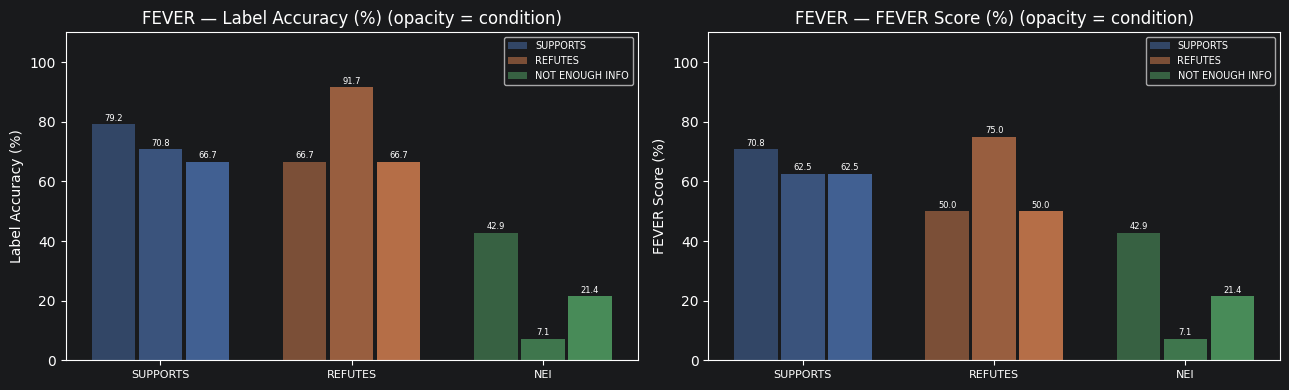

In [18]:
LABEL_ORDER = ['SUPPORTS', 'REFUTES', 'NOT ENOUGH INFO']
LABEL_COLORS = {'SUPPORTS': '#4C72B0', 'REFUTES': '#DD8452', 'NOT ENOUGH INFO': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (metric, ylabel) in zip(axes, [
    ('label_acc', 'Label Accuracy (%)'), ('fever_sc', 'FEVER Score (%)'),
]):
    for i, gold_label in enumerate(LABEL_ORDER):
        color = LABEL_COLORS[gold_label]
        sub = fv[fv['gold_label'] == gold_label]
        if sub.empty: continue
        vals = sub.groupby('condition')[metric].mean().mul(100)
        for j, cond in enumerate(COND_ORDER):
            x = i * 1.1 + j * 0.27
            h = vals.get(cond, 0)
            ax.bar(x, h, width=0.25, color=color,
                   alpha=0.5 + j * 0.15, label=gold_label if j == 0 else '')
            ax.text(x, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=6)
    ax.set_xticks([0.27, 1.37, 2.47])
    ax.set_xticklabels(['SUPPORTS', 'REFUTES', 'NEI'], fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(f'FEVER — {ylabel} (opacity = condition)')
    ax.legend(fontsize=7); ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fever_3cond.png', dpi=150)
plt.show()

## 6 · Poisoning Impact — Cross-Dataset Comparison

- **Δ poison**: `poisoned − clean` — how much poisoning hurt performance
- **Δ recovery**: `poisoned+consistency − poisoned` — how much the consistency prompt recovered

In [19]:
def deltas(df, metrics):
    g = df.groupby('condition')[metrics].mean().reindex(COND_ORDER).mul(100)
    return g.loc['poisoned'] - g.loc['clean'], g.loc['poisoned+consistency'] - g.loc['poisoned']

hq_d_poison, hq_d_recovery = deltas(hq, ['em', 'bleu1', 'f1', 'sp_precision', 'sp_recall', 'sp_f1'])
fv_d_poison, fv_d_recovery = deltas(fv, ['label_acc', 'fever_sc', 'ev_precision', 'ev_recall', 'ev_f1'])

hq_delta_df = pd.DataFrame({
    'Metric':     ['EM', 'BLEU-1', 'Token F1', 'SP Precision', 'SP Recall', 'SP F1'],
    'HQ Δ poison':    hq_d_poison.values.round(1),
    'HQ Δ recovery':  hq_d_recovery.values.round(1),
}).set_index('Metric')

fv_delta_df = pd.DataFrame({
    'Metric':     ['Label Acc', 'FEVER Score', 'Ev. Precision', 'Ev. Recall', 'Ev. F1'],
    'FV Δ poison':    fv_d_poison.values.round(1),
    'FV Δ recovery':  fv_d_recovery.values.round(1),
}).set_index('Metric')

print('Poisoning impact and consistency-prompt recovery (percentage points)\n')
display(pd.concat([hq_delta_df, fv_delta_df]).style.format('{:+.1f}')
        .background_gradient(cmap='RdYlGn_r', subset=['HQ Δ poison', 'FV Δ poison'], axis=None)
        .background_gradient(cmap='RdYlGn',   subset=['HQ Δ recovery', 'FV Δ recovery'], axis=None))

Poisoning impact and consistency-prompt recovery (percentage points)



,HQ Δ poison,HQ Δ recovery,FV Δ poison,FV Δ recovery
Metric,,,,
EM,+2.0,-4.0,+nan,+nan
BLEU-1,+1.1,-8.2,+nan,+nan
Token F1,-0.3,-9.0,+nan,+nan
SP Precision,+0.0,+0.0,+nan,+nan
SP Recall,+0.0,+0.0,+nan,+nan
SP F1,+0.0,+0.0,+nan,+nan
Label Acc,+nan,+nan,-8.0,-4.0
FEVER Score,+nan,+nan,-8.0,-2.0
Ev. Precision,+nan,+nan,+0.0,+0.0


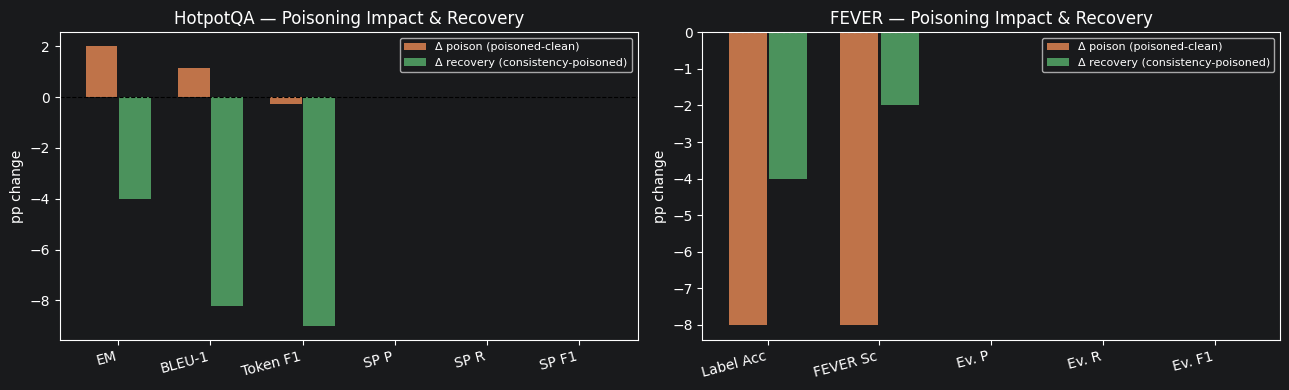

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (delta_poison, delta_recovery, title, bar_labels) in zip(axes, [
    (hq_d_poison, hq_d_recovery, 'HotpotQA',
     ['EM', 'BLEU-1', 'Token F1', 'SP P', 'SP R', 'SP F1']),
    (fv_d_poison, fv_d_recovery, 'FEVER',
     ['Label Acc', 'FEVER Sc', 'Ev. P', 'Ev. R', 'Ev. F1']),
]):
    x = range(len(bar_labels))
    ax.bar([i - 0.18 for i in x], delta_poison.values,
           width=0.34, color='#DD8452', alpha=0.85, label='Δ poison (poisoned-clean)')
    ax.bar([i + 0.18 for i in x], delta_recovery.values,
           width=0.34, color='#55A868', alpha=0.85, label='Δ recovery (consistency-poisoned)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(list(x)); ax.set_xticklabels(bar_labels, rotation=15, ha='right')
    ax.set_ylabel('pp change'); ax.set_title(f'{title} — Poisoning Impact & Recovery')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'poisoning_impact_recovery.png', dpi=150)
plt.show()

## 7 · Faithfulness / Groundedness Score & Hallucination Rate

**Faithfulness score** = P(context entails model output), computed by `cross-encoder/nli-deberta-v3-small`.
Score < 0.5 is flagged as a hallucination.

In [21]:
print('Faithfulness / Groundedness Score by condition\n')

for ds_name, df in [('HotpotQA', hq), ('FEVER', fv)]:
    sub = df[df['faithfulness_score'].notna()]
    if sub.empty:
        print(f'  {ds_name}: no faithfulness data yet (re-run experiments to populate)')
        continue
    summary = (
        sub.groupby('condition')[['faithfulness_score', 'is_hallucination']].mean()
           .reindex([c for c in COND_ORDER if c in sub['condition'].unique()])
           .rename(columns={'faithfulness_score': 'Mean Faithfulness',
                            'is_hallucination':   'Hallucination Rate'})
           .mul({'Mean Faithfulness': 1, 'Hallucination Rate': 100})
           .round(3)
    )
    print(f'  {ds_name}:')
    display(summary.style.format({'Mean Faithfulness': '{:.3f}', 'Hallucination Rate': '{:.1f}%'})
            .background_gradient(cmap='RdYlGn', subset=['Mean Faithfulness'], axis=None)
            .background_gradient(cmap='RdYlGn_r', subset=['Hallucination Rate'], axis=None))

Faithfulness / Groundedness Score by condition

  HotpotQA:


,Mean Faithfulness,Hallucination Rate
condition,,
clean,0.640,38.0%
poisoned,0.666,34.0%
poisoned+consistency,0.671,32.0%


  FEVER:


,Mean Faithfulness,Hallucination Rate
condition,,
clean,0.701,30.0%
poisoned,0.694,28.0%
poisoned+consistency,0.732,24.0%


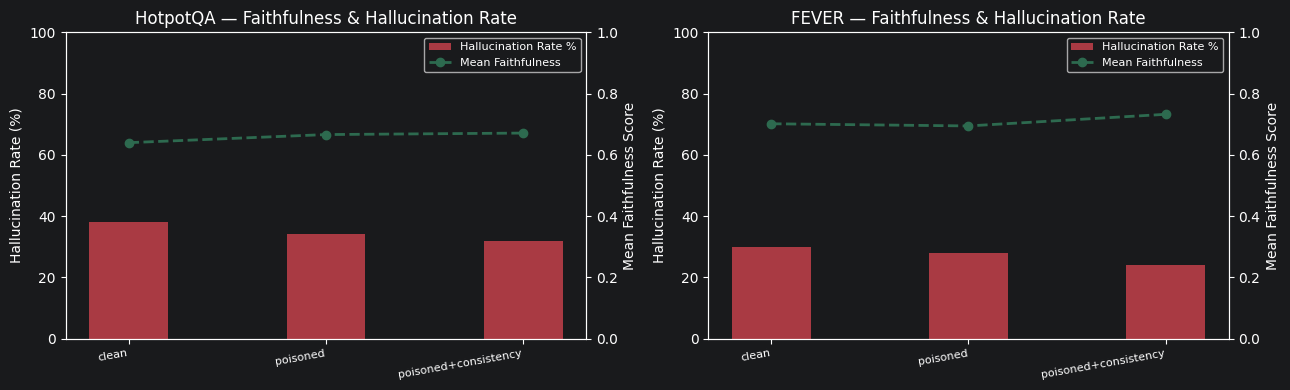

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (ds_name, df, color_key) in zip(axes, [
    ('HotpotQA', hq, '#4C72B0'), ('FEVER', fv, '#DD8452'),
]):
    sub = df[df['faithfulness_score'].notna()]
    if sub.empty:
        ax.set_title(f'{ds_name} — no data')
        continue
    avail = [c for c in COND_ORDER if c in sub['condition'].unique()]
    hall_rates = sub.groupby('condition')['is_hallucination'].mean().reindex(avail).mul(100)
    faith_means = sub.groupby('condition')['faithfulness_score'].mean().reindex(avail)

    x = range(len(avail))
    ax2 = ax.twinx()
    ax.bar(x, hall_rates.values, width=0.4, color='#E84855', alpha=0.7, label='Hallucination Rate %')
    ax2.plot(x, faith_means.values, 'o--', color='#2D6A4F', linewidth=2, label='Mean Faithfulness')
    ax.set_xticks(list(x)); ax.set_xticklabels(avail, rotation=10, ha='right', fontsize=8)
    ax.set_ylabel('Hallucination Rate (%)'); ax2.set_ylabel('Mean Faithfulness Score')
    ax.set_title(f'{ds_name} — Faithfulness & Hallucination Rate')
    ax.set_ylim(0, 100); ax2.set_ylim(0, 1)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'faithfulness_hallucination.png', dpi=150)
plt.show()

## 8 · Error Analysis

3-way join to identify:
- **Poisoning damage**: correct when clean, wrong when poisoned
- **Prompt recovery**: wrong when poisoned, correct again with consistency prompt

In [23]:
def three_way_join_hq(clean_df, poison_df, consist_df):
    base = clean_df[['id', 'question', 'gold_answer', 'pred_answer', 'em', 'type']].copy()
    base = base.merge(
        poison_df[['id', 'pred_answer', 'em']].rename(
            columns={'pred_answer': 'pred_poison', 'em': 'em_poison'}),
        on='id', how='inner')
    base = base.merge(
        consist_df[['id', 'pred_answer', 'em']].rename(
            columns={'pred_answer': 'pred_consist', 'em': 'em_consist'}),
        on='id', how='inner')
    return base

hq3 = three_way_join_hq(hq_clean, hq_poisoned, hq_consist)
damaged   = hq3[(hq3['em'] == 1) & (hq3['em_poison'] == 0)]
recovered = damaged[damaged['em_consist'] == 1]
unrecovered = damaged[damaged['em_consist'] == 0]

print(f'HotpotQA — poisoning damaged {len(damaged)}/{len(hq3)} correct answers')
print(f'  Recovered by consistency prompt: {len(recovered)}')
print(f'  Still wrong after prompt:        {len(unrecovered)}\n')

if not recovered.empty:
    print('-- Sample RECOVERED cases --')
    for _, r in recovered.head(3).iterrows():
        print(f'  [{r["type"]}] {r["question"]}')
        print(f'    Gold:        {r["gold_answer"]}')
        print(f'    Poisoned:    {r["pred_poison"]}')
        print(f'    Consistency: {r["pred_consist"]}  <- correct')
        print()

if not unrecovered.empty:
    print('-- Sample UNRECOVERED cases --')
    for _, r in unrecovered.head(3).iterrows():
        print(f'  [{r["type"]}] {r["question"]}')
        print(f'    Gold:        {r["gold_answer"]}')
        print(f'    Poisoned:    {r["pred_poison"]}')
        print(f'    Consistency: {r["pred_consist"]}  <- still wrong')
        print()

HotpotQA — poisoning damaged 4/50 correct answers
  Recovered by consistency prompt: 1
  Still wrong after prompt:        3

-- Sample RECOVERED cases --
  [bridge] What was the capital of India when the Taj Mahal was commissioned?
    Gold:        Agra
    Poisoned:    I cannot find the answer in the provided context.
    Consistency: Agra  <- correct

-- Sample UNRECOVERED cases --
  [bridge] Black Book starred the actress and writer of what heritage?
    Gold:        Dutch
    Poisoned:    Step 1: Identify relevant information about the film "Black Book".
Step 2: Note that Carice van Houten is one of the main actresses in the film.
Step 3: Find out more about Carice van Houten's heritage by looking at her birthdate and other context passages.
Step 4: Since there is no mention of her heritage in the original passage, we need to look for additional information.

However, I can find that Carice van Houten was born on May 5, 1976, which is not mentioned in the provided context. But anot

In [24]:
def three_way_join_fv(clean_df, poison_df, consist_df):
    base = clean_df[['id', 'claim', 'gold_label', 'pred_label', 'label_acc']].copy()
    base = base.merge(
        poison_df[['id', 'pred_label', 'label_acc']].rename(
            columns={'pred_label': 'pred_poison', 'label_acc': 'acc_poison'}),
        on='id', how='inner')
    base = base.merge(
        consist_df[['id', 'pred_label', 'label_acc']].rename(
            columns={'pred_label': 'pred_consist', 'label_acc': 'acc_consist'}),
        on='id', how='inner')
    return base

fv3 = three_way_join_fv(fv_clean, fv_poisoned, fv_consist)
fv_damaged   = fv3[(fv3['label_acc'] == 1) & (fv3['acc_poison'] == 0)]
fv_recovered = fv_damaged[fv_damaged['acc_consist'] == 1]
fv_unrecovered = fv_damaged[fv_damaged['acc_consist'] == 0]

print(f'FEVER — poisoning damaged {len(fv_damaged)}/{len(fv3)} correct verdicts')
print(f'  Recovered by consistency prompt: {len(fv_recovered)}')
print(f'  Still wrong after prompt:        {len(fv_unrecovered)}\n')

if not fv_recovered.empty:
    print('-- Sample RECOVERED cases --')
    for _, r in fv_recovered.head(3).iterrows():
        print(f'  [{r["gold_label"]}] {r["claim"]}')
        print(f'    Poisoned verdict:     {r["pred_poison"]}')
        print(f'    Consistency verdict:  {r["pred_consist"]}  <- correct')
        print()

if not fv_unrecovered.empty:
    print('-- Sample UNRECOVERED cases --')
    for _, r in fv_unrecovered.head(3).iterrows():
        print(f'  [{r["gold_label"]}] {r["claim"]}')
        print(f'    Poisoned verdict:     {r["pred_poison"]}')
        print(f'    Consistency verdict:  {r["pred_consist"]}  <- still wrong')
        print()

FEVER — poisoning damaged 8/50 correct verdicts
  Recovered by consistency prompt: 1
  Still wrong after prompt:        7

-- Sample RECOVERED cases --
  [NOT ENOUGH INFO] The Beach was adapted for film by John Hodge in 1999.
    Poisoned verdict:     REFUSES
    Consistency verdict:  NOT ENOUGH INFO  <- correct

-- Sample UNRECOVERED cases --
  [NOT ENOUGH INFO] Tilda Swinton is a vegan.
    Poisoned verdict:     REFUTES
    Consistency verdict:  REFUTES  <- still wrong

  [NOT ENOUGH INFO] Asylum Records is an American record label founded in 1971 by David Geffen and musician Elliot Roberts.
    Poisoned verdict:     SUPPORTS
    Consistency verdict:  SUPPORTS  <- still wrong

  [NOT ENOUGH INFO] Dan O'Bannon was a pacifist.
    Poisoned verdict:     REFUSES
    Consistency verdict:  REFUTES  <- still wrong



## 9 · Trust Metrics — Robustness & Transparency

- **Robustness**: Token F1 degradation (clean → poisoned). Positive = performance drop due to poisoning.
- **Transparency**: Fraction of gold supporting sentences entailed by the model's chain-of-thought reasoning (NLI-based). Computed during the HotpotQA experiment run and stored as `transparency_score`.

In [25]:
# ── Robustness ─────────────────────────────────────────────────────────────────
print('=== Robustness (HotpotQA) ===')
clean_f1    = hq_clean['f1'].mean()
poisoned_f1 = hq_poisoned['f1'].mean()
consist_f1  = hq_consist['f1'].mean()
degradation = (clean_f1 - poisoned_f1) * 100
recovery    = (consist_f1 - poisoned_f1) * 100
print(f'  Clean Token F1:              {clean_f1 * 100:.1f}%')
print(f'  Poisoned Token F1:           {poisoned_f1 * 100:.1f}%')
print(f'  Poisoned+Consistency Token F1: {consist_f1 * 100:.1f}%')
print(f'  Robustness score (F1 degradation): {degradation:+.1f} pp')
print(f'  Consistency recovery:              {recovery:+.1f} pp')

print()
print('=== Robustness (FEVER) ===')
fv_clean_acc   = fv_clean['label_acc'].mean()
fv_poison_acc  = fv_poisoned['label_acc'].mean()
fv_consist_acc = fv_consist['label_acc'].mean()
fv_degrad      = (fv_clean_acc - fv_poison_acc) * 100
fv_recovery    = (fv_consist_acc - fv_poison_acc) * 100
print(f'  Clean Label Acc:                   {fv_clean_acc * 100:.1f}%')
print(f'  Poisoned Label Acc:                {fv_poison_acc * 100:.1f}%')
print(f'  Poisoned+Consistency Label Acc:    {fv_consist_acc * 100:.1f}%')
print(f'  Robustness score (Acc degradation):{fv_degrad:+.1f} pp')
print(f'  Consistency recovery:              {fv_recovery:+.1f} pp')

=== Robustness (HotpotQA) ===
  Clean Token F1:              40.0%
  Poisoned Token F1:           39.8%
  Poisoned+Consistency Token F1: 30.8%
  Robustness score (F1 degradation): +0.3 pp
  Consistency recovery:              -9.0 pp

=== Robustness (FEVER) ===
  Clean Label Acc:                   66.0%
  Poisoned Label Acc:                58.0%
  Poisoned+Consistency Label Acc:    54.0%
  Robustness score (Acc degradation):+8.0 pp
  Consistency recovery:              -4.0 pp


In [26]:
# ── Transparency ───────────────────────────────────────────────────────────────
print('=== Transparency (HotpotQA) ===')
print('  Fraction of gold supporting facts entailed by the model\'s reasoning (NLI-based)\n')
for cond_name, d in [('clean', hq_clean), ('poisoned', hq_poisoned), ('consistency', hq_consist)]:
    if 'transparency_score' in d.columns and d['transparency_score'].notna().any():
        ts = d['transparency_score'].dropna()
        print(f'  {cond_name:22s}: {ts.mean() * 100:.1f}%  (n={len(ts)})')
    else:
        print(f'  {cond_name:22s}: not available — re-run the HotpotQA experiments to populate')

=== Transparency (HotpotQA) ===
  Fraction of gold supporting facts entailed by the model's reasoning (NLI-based)

  clean                 : 76.3%  (n=50)
  poisoned              : 80.6%  (n=50)
  consistency           : 75.0%  (n=50)
